# Experiment: Macro-State Correlation Heatmaps

- Reuse the multi-scale macro-state extraction process from `draw_macro_state1.ipynb`.
- For each saved scale, compute the Pearson correlation matrix between macro-state dimensions over time.
- Save the macro-state time series, correlation matrices, and one heatmap per scale.


In [1]:
from __future__ import annotations

import math
import re
import sys
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "src" / "models_macro.py").exists() and (candidate / "src" / "models_micro.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from src.models_macro import Parellel_Renorm_Dynamic as MacroParellelRenormDynamic
from src.models_macro import _build_windows_from_series as build_macro_windows_from_series
from src.models_micro import Parellel_Renorm_Dynamic as MicroParellelRenormDynamic
from src.models_micro import _build_windows_from_series as build_micro_windows_from_series

torch.set_grad_enabled(False)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    pass

DEFAULT_RUN_NAME = "stage2_macro"
DEFAULT_DATA_PATH = Path("loc_data_kuramoto") / "generated_data.npz"


class CompatibleMacroParellelRenormDynamic(MacroParellelRenormDynamic):
    """Allow reconstructing legacy checkpoints that keep a same-dimension macro scale."""

    def _build_scale_dims(self, reduce_dims):
        reduce_dim_schedule = self._resolve_reduce_dims(reduce_dims)
        if len(reduce_dim_schedule) == 1 and int(reduce_dim_schedule[0]) == self.sym_size:
            return (
                [self.sym_size],
                [{"type": "dense", "input_dim": self.sym_size, "output_dim": self.sym_size}],
                reduce_dim_schedule,
            )
        return super()._build_scale_dims(reduce_dims)


In [2]:
PROJECT_ROOT = Path.cwd().resolve()
RUN_NAME = DEFAULT_RUN_NAME
DATA_PATH = DEFAULT_DATA_PATH
MAX_SAMPLES = 2048
USE_TRAIN_SPLIT = True

OUTPUT_DIR = PROJECT_ROOT / "loc_result_stage2" / RUN_NAME / "cal_corr"
STATE_OUTPUT_DIR = OUTPUT_DIR / "macro_state_csv"
CORR_OUTPUT_DIR = OUTPUT_DIR / "corr_csv"
HEATMAP_OUTPUT_DIR = OUTPUT_DIR / "heatmaps"

for directory in (OUTPUT_DIR, STATE_OUTPUT_DIR, CORR_OUTPUT_DIR, HEATMAP_OUTPUT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print({
    "project_root": str(PROJECT_ROOT),
    "run_name": RUN_NAME,
    "data_path": str((PROJECT_ROOT / DATA_PATH).resolve()),
    "max_samples": MAX_SAMPLES,
    "use_train_split": USE_TRAIN_SPLIT,
    "output_dir": str(OUTPUT_DIR.resolve()),
})


{'project_root': '/home/wangzhipeng/code/causal_network/causal_network/kumamoto/causal_network_mix_2_0.2_kuma_theta_inn_sin', 'run_name': 'stage2_macro', 'data_path': '/home/wangzhipeng/code/causal_network/causal_network/kumamoto/causal_network_mix_2_0.2_kuma_theta_inn_sin/loc_data_kuramoto/generated_data.npz', 'max_samples': 2048, 'use_train_split': True, 'output_dir': '/home/wangzhipeng/code/causal_network/causal_network/kumamoto/causal_network_mix_2_0.2_kuma_theta_inn_sin/loc_result_stage2/stage2_macro/cal_corr'}


In [3]:
def find_project_root(start: Optional[Path] = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src" / "models_macro.py").exists() and (candidate / "src" / "models_micro.py").exists() and (candidate / "loc_model_stage2").exists():
            return candidate
    raise FileNotFoundError("Could not locate the causal_network_mix_2_0.2_syn2 project root.")


def parse_reduce_dims(value) -> List[int]:
    if value is None:
        return []
    if isinstance(value, float) and math.isnan(value):
        return []
    text = str(value).strip()
    if text == "" or text.lower() == "nan":
        return []
    return [int(part.strip()) for part in text.split(",") if part.strip()]


def extract_index(path: Path, pattern: str) -> Optional[int]:
    match = re.search(pattern, path.name)
    return None if match is None else int(match.group(1))


def load_array_from_path_local(path: str) -> Optional[np.ndarray]:
    file_path = Path(path)
    if not file_path.exists():
        return None
    suffix = file_path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(file_path, header=None).values.astype(np.float32)
    if suffix == ".npy":
        return np.load(file_path).astype(np.float32)
    if suffix == ".npz":
        with np.load(file_path, allow_pickle=False) as archive:
            if "data" in archive:
                return np.asarray(archive["data"], dtype=np.float32)
            if not archive.files:
                raise ValueError(f"No arrays found in npz file: {file_path}")
            return np.asarray(archive[archive.files[0]], dtype=np.float32)
    raise ValueError(f"Unsupported data file type: {file_path}")


def list_stage2_scale_artifacts(project_root: Path, run_name: str = DEFAULT_RUN_NAME) -> List[Dict]:
    model_dir = project_root / "loc_model_stage2" / run_name
    result_dir = project_root / "loc_result_stage2" / run_name
    if not model_dir.exists():
        raise FileNotFoundError(f"Missing model directory: {model_dir}")
    if not result_dir.exists():
        raise FileNotFoundError(f"Missing result directory: {result_dir}")

    model_map = {
        idx: path
        for path in sorted(model_dir.glob("model_scale*.pkl"))
        for idx in [extract_index(path, r"model_scale(\d+)\.pkl")]
        if idx is not None
    }
    summary_map = {
        idx: path
        for path in sorted(result_dir.glob("summary_scale*.csv"))
        for idx in [extract_index(path, r"summary_scale(\d+)\.csv")]
        if idx is not None
    }

    artifacts = []
    for file_scale in sorted(set(model_map) | set(summary_map)):
        model_path = model_map.get(file_scale)
        summary_path = summary_map.get(file_scale)
        if model_path is None or summary_path is None:
            continue

        summary_row = pd.read_csv(summary_path).iloc[0].to_dict()
        logical_scale_id = int(summary_row.get("scale_id", file_scale))
        scale_dims = parse_reduce_dims(summary_row.get("scale_dims", ""))
        reduce_dims = parse_reduce_dims(summary_row.get("reduce_dims", ""))
        scale_dim = None
        if scale_dims and 0 <= logical_scale_id < len(scale_dims):
            scale_dim = int(scale_dims[logical_scale_id])
        elif reduce_dims:
            if file_scale == 0 and len(reduce_dims) == 1:
                scale_dim = int(reduce_dims[0])
            elif 0 <= logical_scale_id < len(reduce_dims):
                scale_dim = int(reduce_dims[logical_scale_id])

        artifacts.append({
            "file_scale": int(file_scale),
            "model_family": "micro" if int(file_scale) == 0 else "macro",
            "logical_scale_id": logical_scale_id,
            "scale_dim": scale_dim,
            "scale_dims": scale_dims,
            "reduce_dims": reduce_dims,
            "hidden_units1": int(summary_row.get("hidden_units1", 100)),
            "hidden_units2": int(summary_row.get("hidden_units2", 100)),
            "flow_num_layers": int(summary_row.get("flow_num_layers", 3)),
            "dynamics_num_layers": int(summary_row.get("dynamics_num_layers", 4)),
            "latent_size": int(summary_row.get("latent_size", 1)),
            "time_delay": int(summary_row.get("time_delay", 1)),
            "batch_size": int(summary_row.get("batch_size", 1024)),
            "model_path": model_path,
            "summary_path": summary_path,
        })

    if not artifacts:
        raise FileNotFoundError("No paired stage2 macro summary/model artifacts were found.")
    return artifacts


def load_stage2_origin_data(project_root: Path, data_path: Optional[Path] = None) -> np.ndarray:
    resolved_path = project_root / (data_path or DEFAULT_DATA_PATH)
    origin_data = load_array_from_path_local(str(resolved_path))
    if origin_data is None:
        raise FileNotFoundError(f"Could not load origin data from: {resolved_path}")
    return np.asarray(origin_data, dtype=np.float32)


def build_state_windows(origin_data: np.ndarray, time_delay: int, model_family: str, max_samples: Optional[int] = None, use_train_split: bool = True) -> Tuple[np.ndarray, np.ndarray]:
    window_builder = build_micro_windows_from_series if model_family == "micro" else build_macro_windows_from_series
    x_all, y_all = window_builder(origin_data, int(time_delay))
    if use_train_split:
        train_end = max(1, int(len(x_all) * 0.95))
        x_all = x_all[:train_end]
        y_all = y_all[:train_end]
    if max_samples is not None:
        max_samples = int(max_samples)
        x_all = x_all[:max_samples]
        y_all = y_all[:max_samples]
    if len(x_all) == 0:
        raise ValueError("No windows were generated for macro state extraction.")
    return x_all.astype(np.float32), y_all.astype(np.float32)


def build_state_model(num_nodes: int, artifact: Dict, device: torch.device):
    model_cls = MicroParellelRenormDynamic if artifact["model_family"] == "micro" else CompatibleMacroParellelRenormDynamic
    model = model_cls(
        sym_size=int(num_nodes),
        latent_size=int(artifact["latent_size"]),
        effect_size=int(num_nodes),
        cut_size=2,
        hidden_units1=int(artifact["hidden_units1"]),
        hidden_units2=int(artifact["hidden_units2"]),
        normalized_state=True,
        device=device,
        is_random=False,
        flow_num_layers=int(artifact["flow_num_layers"]),
        dynamics_num_layers=int(artifact["dynamics_num_layers"]),
        decode_noise_scale=0.0,
        reduce_dims=artifact["reduce_dims"],
    ).to(device)
    state_dict = torch.load(artifact["model_path"], map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model


def extract_current_inputs(x_windows: np.ndarray) -> np.ndarray:
    if x_windows.ndim == 3:
        return np.asarray(x_windows[:, 0], dtype=np.float32)
    if x_windows.ndim == 2:
        return np.asarray(x_windows, dtype=np.float32)
    raise ValueError(f"x_windows must have shape [B, T, N] or [B, N], but got {x_windows.shape}")


def compute_macro_state_for_scale(
    artifact: Dict,
    origin_data: np.ndarray,
    device: Union[str, torch.device] = "cpu",
    max_samples: Optional[int] = None,
    use_train_split: bool = True,
) -> Dict:
    device = torch.device(device)
    model = build_state_model(origin_data.shape[-1], artifact, device=device)
    x_np, _ = build_state_windows(
        origin_data,
        time_delay=artifact["time_delay"],
        model_family=artifact["model_family"],
        max_samples=max_samples,
        use_train_split=use_train_split,
    )
    source_np = extract_current_inputs(x_np)
    source_tensor = torch.tensor(source_np, dtype=torch.float32, device=device)
    macro_states = model.encoding1(source_tensor, artifact["logical_scale_id"])[artifact["logical_scale_id"]]
    return {
        **artifact,
        "num_windows": int(len(x_np)),
        "num_samples": int(len(source_np)),
        "input_dim": int(source_np.shape[-1]),
        "macro_states": macro_states.detach().cpu().numpy().astype(np.float32),
    }


def save_macro_state_results(
    results: List[Dict],
    output_dir: Path,
    file_name_template: str = "macro_state_scale{file_scale}.csv",
) -> List[Path]:
    output_dir.mkdir(parents=True, exist_ok=True)
    saved_paths = []
    for item in results:
        columns = [f"macro_state_{idx}" for idx in range(item["macro_states"].shape[1])]
        output_path = output_dir / file_name_template.format(file_scale=item["file_scale"])
        pd.DataFrame(item["macro_states"], columns=columns).to_csv(output_path, index=False)
        saved_paths.append(output_path)
    return saved_paths


def compute_macro_states_for_all_scales(
    project_root: Optional[Path] = None,
    run_name: str = DEFAULT_RUN_NAME,
    data_path: Optional[Path] = None,
    device: Union[str, torch.device] = "cpu",
    max_samples: Optional[int] = None,
    use_train_split: bool = True,
    output_dir: Optional[Path] = None,
) -> Tuple[pd.DataFrame, List[Dict]]:
    project_root = find_project_root(project_root)
    origin_data = load_stage2_origin_data(project_root, data_path=data_path)
    artifacts = list_stage2_scale_artifacts(project_root, run_name=run_name)
    results = [
        compute_macro_state_for_scale(
            artifact,
            origin_data,
            device=device,
            max_samples=max_samples,
            use_train_split=use_train_split,
        )
        for artifact in artifacts
    ]

    if output_dir is None:
        output_dir = project_root / "loc_result_stage2" / run_name / "cal_corr" / "macro_state_csv"
    output_dir = Path(output_dir)
    state_paths = save_macro_state_results(results, output_dir=output_dir)

    summary_rows = []
    for item, state_path in zip(results, state_paths):
        summary_rows.append({
            "file_scale": item["file_scale"],
            "model_family": item["model_family"],
            "logical_scale_id": item["logical_scale_id"],
            "scale_dim": item["scale_dim"],
            "time_delay": item["time_delay"],
            "num_windows": item["num_windows"],
            "num_samples": item["num_samples"],
            "input_dim": item["input_dim"],
            "state_dim": int(item["macro_states"].shape[1]),
            "model_path": str(item["model_path"].resolve()),
            "summary_path": str(item["summary_path"].resolve()),
            "macro_state_csv": str(state_path.resolve()),
        })
    return pd.DataFrame(summary_rows).sort_values("file_scale").reset_index(drop=True), results


def compute_pearson_corr_matrix(states: np.ndarray) -> np.ndarray:
    states = np.asarray(states, dtype=np.float32)
    if states.ndim != 2:
        raise ValueError(f"states must have shape [time_steps, state_dim], but got {states.shape}")
    state_dim = int(states.shape[1])
    if state_dim == 1:
        return np.ones((1, 1), dtype=np.float32)
    corr = np.corrcoef(states, rowvar=False).astype(np.float32)
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(corr, 1.0)
    return corr


def save_corr_matrix(corr_matrix: np.ndarray, file_scale: int, output_dir: Path) -> Path:
    output_dir.mkdir(parents=True, exist_ok=True)
    columns = [f"macro_state_{idx}" for idx in range(corr_matrix.shape[1])]
    output_path = output_dir / f"corr_scale{file_scale}.csv"
    pd.DataFrame(corr_matrix, index=columns, columns=columns).to_csv(output_path, index=True)
    return output_path


def plot_corr_heatmap(
    corr_matrix: np.ndarray,
    file_scale: int,
    logical_scale_id: int,
    output_dir: Path,
) -> Path:
    corr_matrix = np.asarray(corr_matrix, dtype=np.float32)
    state_dim = int(corr_matrix.shape[0])
    fig_size = 4.8 if state_dim <= 4 else 6.2 if state_dim <= 8 else 8.0
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1.0, vmax=1.0, origin="upper")
    labels = [f"m{idx}" for idx in range(state_dim)]
    ax.set_xticks(np.arange(state_dim))
    ax.set_yticks(np.arange(state_dim))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("macro-state dimension")
    ax.set_ylabel("macro-state dimension")
    ax.set_title(
        f"Pearson correlation heatmap | file_scale={file_scale} | "
        f"logical_scale_id={logical_scale_id} | state_dim={state_dim}"
    )

    if state_dim <= 8:
        for row_idx in range(state_dim):
            for col_idx in range(state_dim):
                value = corr_matrix[row_idx, col_idx]
                text_color = "white" if abs(value) > 0.55 else "black"
                ax.text(col_idx, row_idx, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=9)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Pearson r")
    fig.tight_layout()

    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"corr_heatmap_scale{file_scale}.png"
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return output_path


def compute_corr_results_for_all_scales(
    state_results: List[Dict],
    corr_output_dir: Path,
    heatmap_output_dir: Path,
) -> pd.DataFrame:
    rows = []
    for item in sorted(state_results, key=lambda row: row["file_scale"]):
        corr_matrix = compute_pearson_corr_matrix(item["macro_states"])
        corr_csv_path = save_corr_matrix(corr_matrix, file_scale=item["file_scale"], output_dir=corr_output_dir)
        heatmap_path = plot_corr_heatmap(
            corr_matrix=corr_matrix,
            file_scale=item["file_scale"],
            logical_scale_id=item["logical_scale_id"],
            output_dir=heatmap_output_dir,
        )
        rows.append({
            "file_scale": item["file_scale"],
            "model_family": item["model_family"],
            "logical_scale_id": item["logical_scale_id"],
            "state_dim": int(item["macro_states"].shape[1]),
            "corr_trace": float(np.trace(corr_matrix)),
            "corr_mean_abs_offdiag": float(np.mean(np.abs(corr_matrix - np.eye(corr_matrix.shape[0], dtype=np.float32)))) if corr_matrix.shape[0] > 1 else 0.0,
            "corr_csv_path": str(corr_csv_path.resolve()),
            "heatmap_path": str(heatmap_path.resolve()),
        })
    return pd.DataFrame(rows).sort_values("file_scale").reset_index(drop=True)


In [4]:
PROJECT_ROOT = find_project_root(PROJECT_ROOT)

STATE_SUMMARY_DF, STATE_RESULTS = compute_macro_states_for_all_scales(
    project_root=PROJECT_ROOT,
    run_name=RUN_NAME,
    data_path=DATA_PATH,
    device="cpu",
    max_samples=MAX_SAMPLES,
    use_train_split=USE_TRAIN_SPLIT,
    output_dir=STATE_OUTPUT_DIR,
)

STATE_SUMMARY_DF


RuntimeError: Error(s) in loading state_dict for Parellel_Renorm_Dynamic:
	Missing key(s) in state_dict: "group_transitions.0.flow.encoder.0.weight", "group_transitions.0.flow.encoder.0.bias", "group_transitions.0.flow.encoder.2.weight", "group_transitions.0.flow.encoder.2.bias", "group_transitions.0.flow.encoder.4.weight", "group_transitions.0.flow.encoder.4.bias", "group_transitions.0.flow.decoder.0.weight", "group_transitions.0.flow.decoder.0.bias", "group_transitions.0.flow.decoder.2.weight", "group_transitions.0.flow.decoder.2.bias", "group_transitions.0.flow.decoder.4.weight", "group_transitions.0.flow.decoder.4.bias". 
	Unexpected key(s) in state_dict: "group_transitions.0.flow.flow.mask", "group_transitions.0.flow.flow.t.0.0.weight", "group_transitions.0.flow.flow.t.0.0.bias", "group_transitions.0.flow.flow.t.0.2.weight", "group_transitions.0.flow.flow.t.0.2.bias", "group_transitions.0.flow.flow.t.0.4.weight", "group_transitions.0.flow.flow.t.0.4.bias", "group_transitions.0.flo

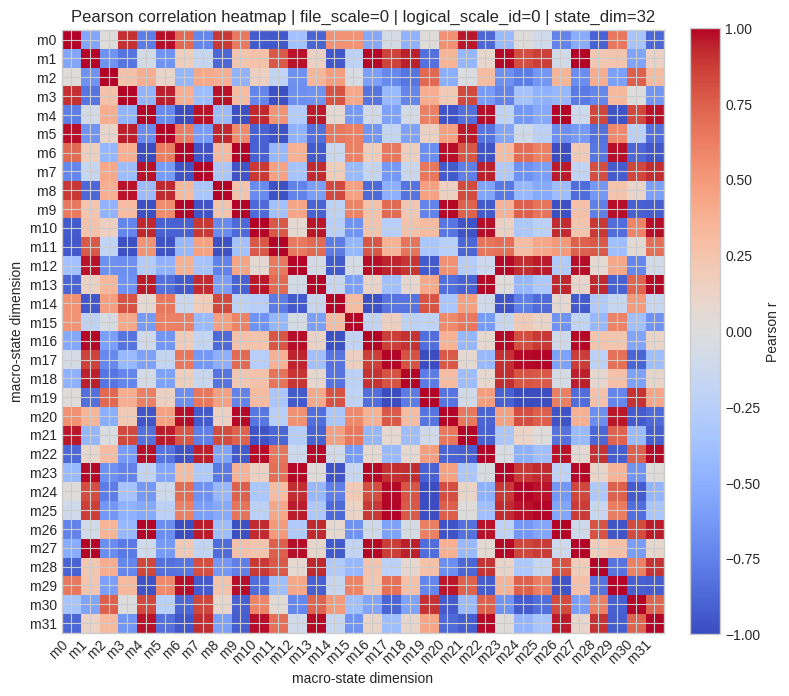

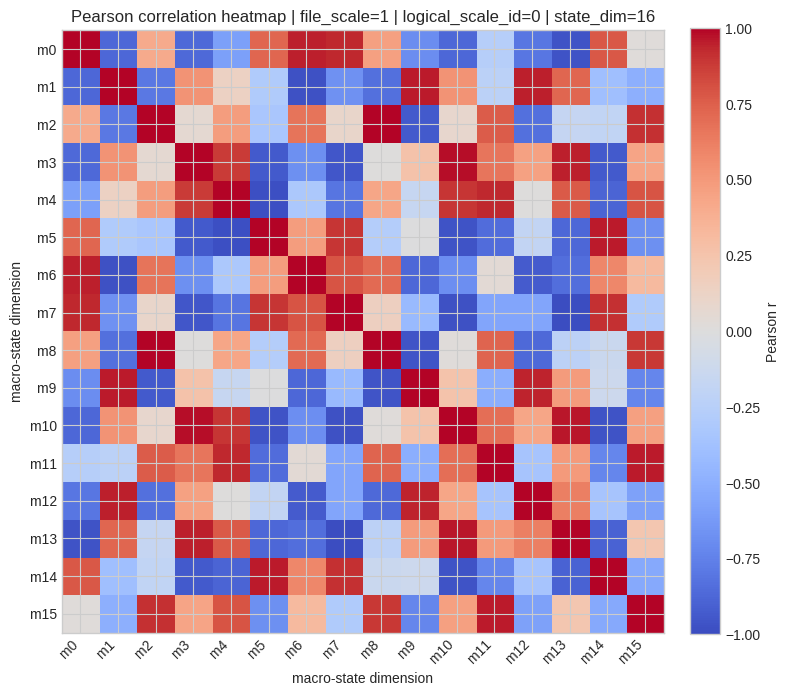

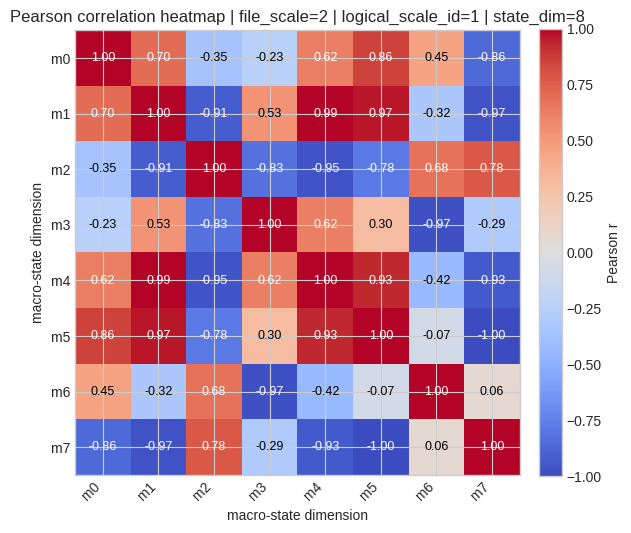

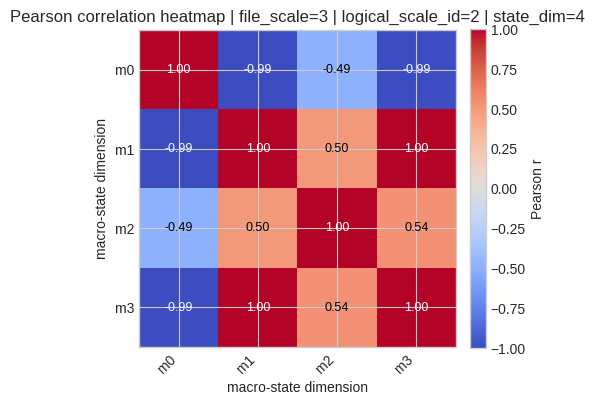

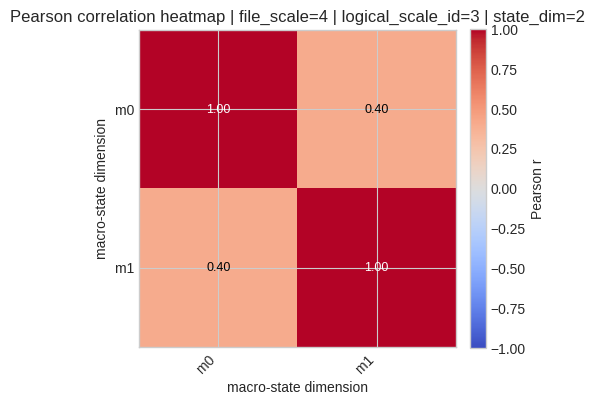

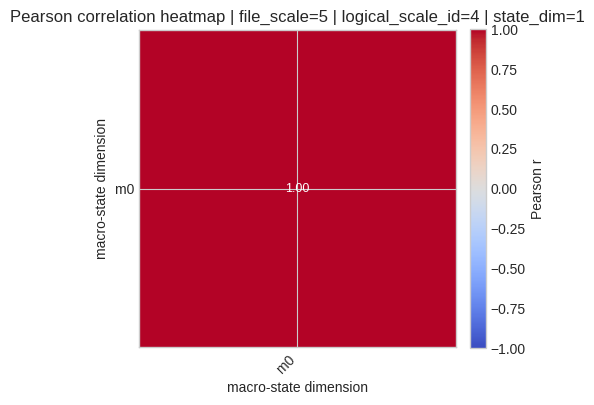

,file_scale,model_family,logical_scale_id,state_dim,corr_trace,corr_mean_abs_offdiag,corr_csv_path,heatmap_path
0,0,micro,0,32,32.0,0.566096,/home/wangzhipeng/code/causal_network/causal_n...,/home/wangzhipeng/code/causal_network/causal_n...
1,1,macro,0,16,16.0,0.571789,/home/wangzhipeng/code/causal_network/causal_n...,/home/wangzhipeng/code/causal_network/causal_n...
2,2,macro,1,8,8.0,0.574738,/home/wangzhipeng/code/causal_network/causal_n...,/home/wangzhipeng/code/causal_network/causal_n...
3,3,macro,2,4,4.0,0.564122,/home/wangzhipeng/code/causal_network/causal_n...,/home/wangzhipeng/code/causal_network/causal_n...
4,4,macro,3,2,2.0,0.199630,/home/wangzhipeng/code/causal_network/causal_n...,/home/wangzhipeng/code/causal_network/causal_n...
5,5,macro,4,1,1.0,0.000000,/home/wangzhipeng/code/causal_network/causal_n...,/home/wangzhipeng/code/causal_network/causal_n...


In [ ]:
CORR_SUMMARY_DF = compute_corr_results_for_all_scales(
    state_results=STATE_RESULTS,
    corr_output_dir=CORR_OUTPUT_DIR,
    heatmap_output_dir=HEATMAP_OUTPUT_DIR,
)

CORR_SUMMARY_DF


In [6]:
display(STATE_SUMMARY_DF[["file_scale", "model_family", "logical_scale_id", "state_dim", "macro_state_csv"]])
display(CORR_SUMMARY_DF[["file_scale", "state_dim", "corr_csv_path", "heatmap_path"]])


,file_scale,model_family,logical_scale_id,state_dim,macro_state_csv
0,0,micro,0,32,/home/wangzhipeng/code/causal_network/causal_n...
1,1,macro,0,16,/home/wangzhipeng/code/causal_network/causal_n...
2,2,macro,1,8,/home/wangzhipeng/code/causal_network/causal_n...
3,3,macro,2,4,/home/wangzhipeng/code/causal_network/causal_n...
4,4,macro,3,2,/home/wangzhipeng/code/causal_network/causal_n...
5,5,macro,4,1,/home/wangzhipeng/code/causal_network/causal_n...


,file_scale,state_dim,corr_csv_path,heatmap_path
0,0,32,/home/wangzhipeng/code/causal_network/causal_n...,/home/wangzhipeng/code/causal_network/causal_n...
1,1,16,/home/wangzhipeng/code/causal_network/causal_n...,/home/wangzhipeng/code/causal_network/causal_n...
2,2,8,/home/wangzhipeng/code/causal_network/causal_n...,/home/wangzhipeng/code/causal_network/causal_n...
3,3,4,/home/wangzhipeng/code/causal_network/causal_n...,/home/wangzhipeng/code/causal_network/causal_n...
4,4,2,/home/wangzhipeng/code/causal_network/causal_n...,/home/wangzhipeng/code/causal_network/causal_n...
5,5,1,/home/wangzhipeng/code/causal_network/causal_n...,/home/wangzhipeng/code/causal_network/causal_n...
